In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('../raw/manhwa_data_complete.csv')

In [20]:
df.head()

,id,title,score,popularity,genres,tags,main_char,description
0,105398,Solo Leveling,84.0,276303,Action|Adventure|Fantasy,Dungeon:95|Male Protagonist:93|Super Power:92|...,Jin-U Seong,In a world where awakened beings called “Hunte...
1,119257,Omniscient Reader,86.0,125487,Action|Adventure|Fantasy,Survival:97|Post-Apocalyptic:94|Death Game:88|...,Dok-Ja Kim,"Back then, Dok-Ja had no idea. He had no idea ..."
2,85143,Tower of God,81.0,97356,Action|Adventure|Drama|Fantasy|Mystery,Super Power:95|Ensemble Cast:93|Full Color:91|...,Twenty-Fifth Baam,What do you desire? Money and wealth? Honor an...
3,86964,Bastard,83.0,74892,Drama|Horror|Mystery|Psychological|Romance|Thr...,Crime:90|Tragedy:88|Male Protagonist:87|Gore:8...,Jin Seon,"High school life is hard enough, but it’s even..."
4,128067,SSS-Class Revival Hunter,83.0,63166,Action|Adventure|Drama|Fantasy|Supernatural,Time Manipulation:95|Male Protagonist:92|Full ...,Gong-Ja Kim,"In the mysterious, RPG dungeon-like Tower, Con..."


Need to train the recommender system/model from genres, tags, and descriptions. These are the most important features to focus on. Popularity and score will probably skew the model and train it on "what's popular" versus "what's similiar"

In [21]:
# Drop duplicates
df.drop_duplicates(subset='id', inplace=True)
# Set id as the index
df = df.set_index('id')

In [22]:
# Considering dropping or keeping series with no description or tags in a separate pool
no_tags_desc = df[
    (df['tags'].isnull()   | (df['tags'].str.strip()   == '')) &
    (df['description'].isnull() | (df['description'].str.strip() == ''))
]
# Dropping ids with no tags or descriptions for model training
print(f"Before: {len(df)}")
df.drop(no_tags_desc.index, inplace=True)
print(f"After: {len(df)}")
print(f"Rows dropped {len(no_tags_desc)} rows")

Before: 4974
After: 4952
Rows dropped 22 rows


In [ ]:
# Separating features
genres = df[['genres']]
tags = df[['tags']]
descriptions = df[['description']]

In [23]:
# Genres need to be split to be encoded correctly
genres_stripped = df['genres'].str.get_dummies(sep='|')

In [16]:
# Looking into the data
genre_counts = genres_stripped.sum().sort_values(ascending=False)
genre_counts


Romance          3287
Drama            2623
Fantasy          2228
Action           1125
Comedy            870
Hentai            834
Supernatural      535
Adventure         466
Slice of Life     337
Psychological     271
Mystery           203
Thriller          126
Horror            110
Sci-Fi             94
Sports             56
Ecchi              37
Music              24
Mahou Shoujo        5
Mecha               3
dtype: int64

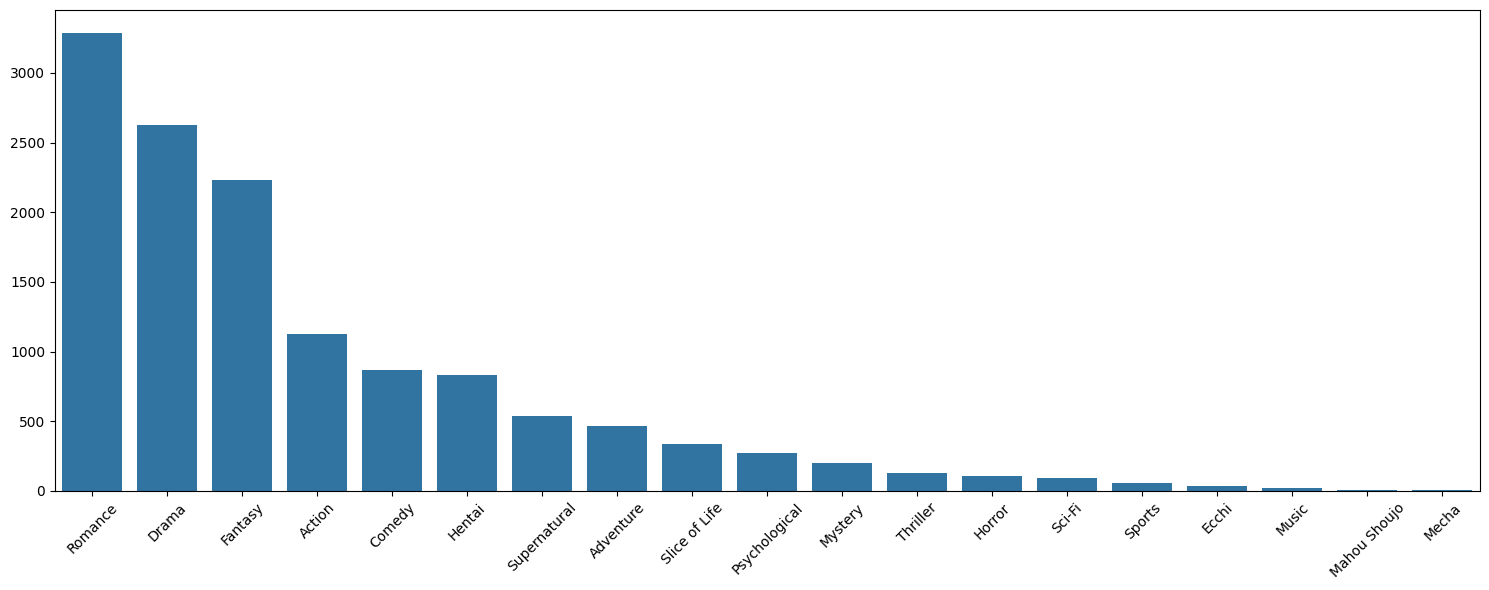

In [17]:
fig, ax = plt.subplots(figsize=(15,6))
ax.tick_params(axis='x', labelrotation=45)
genre_plot = sns.barplot(data=genre_counts, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# Need to remove genres that are less than 1% of the total; effectively just noise in our data
THRESHOLD = np.floor(len(df) * 0.01)
genres_to_drop = [col for col in genres_stripped if genres_stripped[col].sum() < THRESHOLD]

KeyError: 'id'

In [ ]:
genres_cleaned = genres_stripped.drop(columns=genres_to_drop)

In [ ]:
# Checking to see if any titles are just are 0 now since that I dropped niche genres
niche_titles_sum = genres_cleaned.eq(0).all(axis=1).sum()
print(niche_titles_sum)

0
